In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
print('all resources imported successfully')

all resources imported successfully


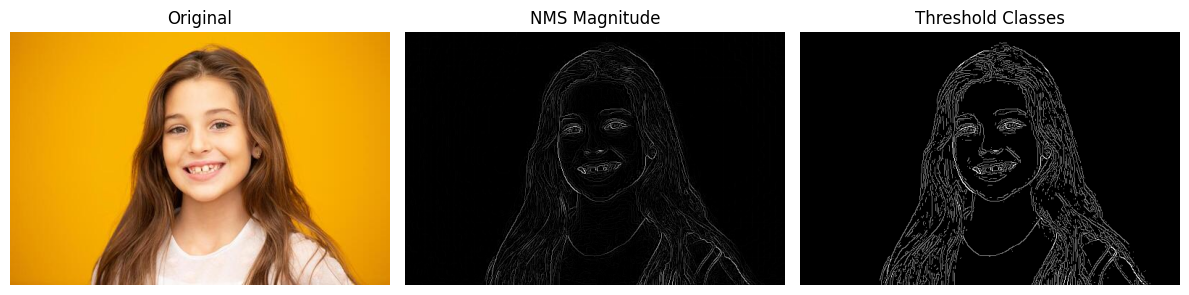

In [6]:
# Set your image path here
IMAGE_PATH = "portrait-of-a-happy-smiling-child-girl-in-yellow-background-photo.jpg"
weak_th = None
strong_th = None

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at path: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Sobel gradients
gx = cv2.Sobel(np.float32(img_gray), cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(np.float32(img_gray), cv2.CV_64F, 0, 1, ksize=3)
mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)

height, width = img_gray.shape
mag_max = np.max(mag)

if weak_th is None:
    weak_th = mag_max * 0.1

if strong_th is None:
    strong_th = mag_max * 0.5

# Non-maximum suppression
nms = mag.copy()
for i_x in range(width):
    for i_y in range(height):
        grad_ang = ang[i_y, i_x]
        grad_ang = abs(grad_ang - 180) if abs(grad_ang) > 180 else abs(grad_ang)

        if grad_ang <= 22.5:
            neighbor_1_x, neighbor_1_y = i_x - 1, i_y
            neighbor_2_x, neighbor_2_y = i_x + 1, i_y
        elif 22.5 < grad_ang <= 67.5:
            neighbor_1_x, neighbor_1_y = i_x - 1, i_y - 1
            neighbor_2_x, neighbor_2_y = i_x + 1, i_y + 1
        elif 67.5 < grad_ang <= 112.5:
            neighbor_1_x, neighbor_1_y = i_x, i_y - 1
            neighbor_2_x, neighbor_2_y = i_x, i_y + 1
        elif 112.5 < grad_ang <= 157.5:
            neighbor_1_x, neighbor_1_y = i_x - 1, i_y + 1
            neighbor_2_x, neighbor_2_y = i_x + 1, i_y - 1
        else:
            neighbor_1_x, neighbor_1_y = i_x - 1, i_y
            neighbor_2_x, neighbor_2_y = i_x + 1, i_y

        if (0 <= neighbor_1_x < width) and (0 <= neighbor_1_y < height):
            if nms[i_y, i_x] < nms[neighbor_1_y, neighbor_1_x]:
                nms[i_y, i_x] = 0
                continue

        if (0 <= neighbor_2_x < width) and (0 <= neighbor_2_y < height):
            if nms[i_y, i_x] < nms[neighbor_2_y, neighbor_2_x]:
                nms[i_y, i_x] = 0

# Double-threshold classification: 0=non-edge, 1=weak, 2=strong
ids = np.zeros_like(img_gray, dtype=np.uint8)
for i_x in range(width):
    for i_y in range(height):
        grad_mag = nms[i_y, i_x]
        if grad_mag < weak_th:
            ids[i_y, i_x] = 0
        elif weak_th <= grad_mag < strong_th:
            ids[i_y, i_x] = 1
        else:
            ids[i_y, i_x] = 2

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nms, cmap="gray")
plt.title("NMS Magnitude")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(ids, cmap="gray")
plt.title("Threshold Classes")
plt.axis("off")

plt.tight_layout()
plt.show()